# HPC vs SMC — Region Comparison

Reads the CSVs produced by `vascular_graph_analysis.ipynb` for each region and compares them.

**Run `vascular_graph_analysis.ipynb` for both HPC and SMC before running this notebook.**

---
**Sections:**
1. [Configuration & data loading](#1-configuration--data-loading)
2. [Helper functions](#2-helper-functions)
3. [Vessel density](#3-vessel-density)
4. [Diameter & length by vessel type](#4-diameter--length-by-vessel-type)
5. [Boundary conditions](#5-boundary-conditions)
6. [Connectivity — min-cut & redundancy](#6-connectivity--min-cut--redundancy)
7. [Saturation](#7-saturation)
8. [Major tree coverage](#8-major-tree-coverage)
9. [Save all stats](#9-save-all-stats)

---
## 1. Configuration & data loading

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# =====================================================================
# PATHS
# =====================================================================
HPC_DIR = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
SMC_DIR = "/home/admin/Ana/MicroBrain/output/SMC_FULL_ANALYSIS_FORMATTED"
OUT_DIR = "/home/admin/Ana/MicroBrain/output/HPC_vs_SMC_STATS"
os.makedirs(OUT_DIR, exist_ok=True)

# =====================================================================
# COLORS & ORDER
# =====================================================================
REGION_COL  = {"HPC": "tab:blue", "SMC": "tab:orange"}
TYPE_ORDER  = ("arteriole", "venule", "capillary")
REGION_ORDER = ("HPC", "SMC")

# =====================================================================
# FILE MAP  — matches names produced by vascular_graph_analysis.ipynb
# =====================================================================
FILE_MAP = {
    "summary":     "{region}_summary.csv",
    "density":     "{region}_density_subboxes.csv",
    "diam_length": "{region}_diameter_length.csv",
    "bc_pooled":   "{region}_bc_pooled.csv",
    "bc_long":     "{region}_bc_diameter_long.csv",
    "saturation":  "{region}_saturation.csv",
    "mincut":      "{region}_mincut.csv",
    "redundancy":  "{region}_redundancy.csv",
}

REGION_DIRS = {"HPC": HPC_DIR, "SMC": SMC_DIR}

def load_both(key, region_col="region"):
    """Load a CSV for both regions and tag with region column."""
    dfs = []
    for region in REGION_ORDER:
        fname = FILE_MAP[key].format(region=region)
        path  = os.path.join(REGION_DIRS[region], fname)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df[region_col] = region
            dfs.append(df)
        else:
            print(f"[WARNING] Not found: {path}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# =====================================================================
# LOAD ALL DATA
# =====================================================================
summary     = load_both("summary")
density_all = load_both("density")
dl_all      = load_both("diam_length")
bc_pooled   = load_both("bc_pooled")
bc_long     = load_both("bc_long")
saturation  = load_both("saturation")
mincut      = load_both("mincut")
redundancy  = load_both("redundancy")

print(f"summary     : {summary.shape}")
print(f"density_all : {density_all.shape}")
print(f"dl_all      : {dl_all.shape}")
print(f"bc_pooled   : {bc_pooled.shape}")
print(f"bc_long     : {bc_long.shape}")
print(f"saturation  : {saturation.shape}")
print(f"mincut      : {mincut.shape}")
print(f"redundancy  : {redundancy.shape}")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


summary     : (6, 69)
density_all : (8232, 5)
dl_all      : (7998, 5)
bc_pooled   : (17, 9)
bc_long     : (1962, 6)
saturation  : (9, 20)
mincut      : (6, 11)
redundancy  : (6, 11)


---
## 2. Helper functions

In [9]:
# =====================================================================
# STATS HELPERS
# =====================================================================
def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _normalize_types(df, col="type"):
    d = df.copy()
    d[col] = d[col].astype(str).str.lower().str.strip()
    d[col] = d[col].replace({
        "artery": "arteriole", "arterial": "arteriole",
        "vein": "venule",      "venous": "venule",
        "cap": "capillary",
    })
    return d

def _p_to_text(p):
    if not np.isfinite(p): return "p=NA"
    if p < 1e-4:           return "p<1e-4"
    return f"p={p:.3g}"

def welch_row(x1, x2, label, extra=None):
    x1, x2 = _finite(x1), _finite(x2)
    if x1.size < 2 or x2.size < 2:
        t_stat, p_val = np.nan, np.nan
    else:
        t_stat, p_val = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
    row = {
        "metric":     label,
        "HPC_n":      int(x1.size),
        "SMC_n":      int(x2.size),
        "HPC_mean":   float(np.mean(x1))   if x1.size else np.nan,
        "SMC_mean":   float(np.mean(x2))   if x2.size else np.nan,
        "HPC_median": float(np.median(x1)) if x1.size else np.nan,
        "SMC_median": float(np.median(x2)) if x2.size else np.nan,
        "t_stat":     float(t_stat) if np.isfinite(t_stat) else np.nan,
        "p_value":    float(p_val)  if np.isfinite(p_val)  else np.nan,
    }
    if extra: row.update(extra)
    return row

# =====================================================================
# PLOT HELPERS
# =====================================================================
def add_jitter_scatter(ax, xpos, y, color="black", jitter=0.08, alpha=0.08, s=5, max_points=2000):
    y = _finite(y)
    if y.size == 0: return
    rng = np.random.default_rng(0)
    if y.size > max_points:
        y = rng.choice(y, size=max_points, replace=False)
    xj = xpos + rng.uniform(-jitter, jitter, size=y.size)
    ax.scatter(xj, y, s=s, alpha=alpha, color=color, edgecolors="none", zorder=2)

def add_two_group_pvalue(ax, x1, x2, y_top_data, p, fontsize=9):
    y0, y1 = ax.get_ylim()
    yr = max(y1 - y0, 1.0)
    y  = y_top_data + 0.05 * yr
    h  = 0.025 * yr
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.1, c="black", zorder=5)
    ax.text((x1+x2)/2, y+h+0.012*yr, _p_to_text(p),
            ha="center", va="bottom", fontsize=fontsize, zorder=6)
    needed = y + h + 0.036*yr
    if needed > y1:
        ax.set_ylim(y0, needed + 0.03*yr)

def plot_region_metric_boxplot(df, value_col, ylabel, title, out_path=None):
    """Single boxplot: HPC vs SMC for one metric."""
    hpc = _finite(df.loc[df["region"]=="HPC", value_col].to_numpy(float))
    smc = _finite(df.loc[df["region"]=="SMC", value_col].to_numpy(float))
    if hpc.size == 0 or smc.size == 0:
        print(f"[skip] {value_col} — missing data for one region")
        return pd.DataFrame()

    stat_row = welch_row(hpc, smc, value_col)

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    bp = ax.boxplot([hpc, smc], labels=["HPC","SMC"], showfliers=False, patch_artist=True)
    for patch, lab in zip(bp["boxes"], ["HPC","SMC"]):
        patch.set_facecolor(REGION_COL[lab])
        patch.set_alpha(0.30)
    add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=22, alpha=0.30, max_points=5000)
    add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=22, alpha=0.30, max_points=5000)
    add_two_group_pvalue(ax, 1, 2, max(np.max(hpc), np.max(smc)), stat_row["p_value"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame([stat_row])

def plot_region_by_type_boxplots(df, value_col, ylabel, title, type_col="type", out_path=None):
    """One panel per vessel type: HPC vs SMC."""
    df = _normalize_types(df, col=type_col)
    types_present = [t for t in TYPE_ORDER if t in df[type_col].unique()]

    fig, axes = plt.subplots(1, len(types_present),
                              figsize=(4.8*len(types_present), 5.0), sharey=False)
    if len(types_present) == 1: axes = [axes]

    stats_rows = []
    for ax, t in zip(axes, types_present):
        sub = df[df[type_col] == t]
        hpc = _finite(sub.loc[sub["region"]=="HPC", value_col].to_numpy(float))
        smc = _finite(sub.loc[sub["region"]=="SMC", value_col].to_numpy(float))
        if hpc.size == 0 or smc.size == 0:
            ax.set_axis_off(); continue

        stat_row = welch_row(hpc, smc, value_col, extra={"type": t})
        stats_rows.append(stat_row)

        bp = ax.boxplot([hpc, smc], labels=["HPC","SMC"], showfliers=False, patch_artist=True)
        for patch, lab in zip(bp["boxes"], ["HPC","SMC"]):
            patch.set_facecolor(REGION_COL[lab])
            patch.set_alpha(0.30)
        add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=10, alpha=0.20, max_points=2000)
        add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=10, alpha=0.20, max_points=2000)
        add_two_group_pvalue(ax, 1, 2, max(np.max(hpc), np.max(smc)), stat_row["p_value"])
        ax.set_title(t)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25, axis="y")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(stats_rows)


def plot_bc_kind_distribution(bc_pooled_all, out_path=None):
    """Grouped bar: boundary-face vessel type % — HPC vs SMC."""
    df = bc_pooled_all.copy()
    # normaliza nombre de columna
    if "type" in df.columns and "vessel_type" not in df.columns:
        df = df.rename(columns={"type": "vessel_type"})
    df = _normalize_types(df, col="vessel_type")

    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    x      = np.arange(len(TYPE_ORDER), dtype=float)
    width  = 0.34
    offsets = {"HPC": -width/2, "SMC": width/2}
    stats_rows = []
    rng = np.random.default_rng(0)

    for i, vt in enumerate(TYPE_ORDER):
        sub = df[df["vessel_type"] == vt]
        hpc = _finite(sub.loc[sub["region"]=="HPC", "pct"].to_numpy(float))
        smc = _finite(sub.loc[sub["region"]=="SMC", "pct"].to_numpy(float))

        for lab, vals in [("HPC", hpc), ("SMC", smc)]:
            if vals.size:
                ax.bar(x[i]+offsets[lab], np.mean(vals), width=width,
                       color=REGION_COL[lab], alpha=0.45, edgecolor="black", linewidth=0.6)
                ax.scatter(
                    np.full(vals.size, x[i]+offsets[lab]) + rng.uniform(-0.04, 0.04, vals.size),
                    vals, s=32, color=REGION_COL[lab], alpha=0.85, zorder=3, edgecolors="none")

        row = welch_row(hpc, smc, "BC_pct", extra={"vessel_type": vt})
        stats_rows.append(row)
        if hpc.size and smc.size:
            add_two_group_pvalue(ax, x[i]+offsets["HPC"], x[i]+offsets["SMC"],
                                 max(np.max(hpc), np.max(smc)), row["p_value"], fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(TYPE_ORDER, fontsize=12)
    ax.set_ylabel("Boundary-face composition (%)", fontsize=11)
    ax.set_title("Boundary-face vessel type distribution | HPC vs SMC", fontsize=13)
    ax.grid(alpha=0.25, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(handles=[
        plt.Line2D([0],[0], marker="s", linestyle="", color=REGION_COL[r], label=r, markersize=10)
        for r in REGION_ORDER], frameon=False, fontsize=10)
    plt.tight_layout()
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(stats_rows)


print("Helpers loaded.")

Helpers loaded.


---
## 3. Vessel density

In [11]:
def plot_region_by_type_boxplots(df, value_col, ylabel, title,
                                  type_col="type", out_path=None, clip_pct=98):
    df = _normalize_types(df, col=type_col)
    types_present = [t for t in TYPE_ORDER if t in df[type_col].unique()]
    if not types_present:
        print(f"[skip] no vessel types found for {value_col}")
        return pd.DataFrame()

    fig, axes = plt.subplots(1, len(types_present),
                              figsize=(4.8*len(types_present), 5.2), sharey=False)
    if len(types_present) == 1:
        axes = [axes]

    stats_rows = []
    for ax, t in zip(axes, types_present):
        sub = df[df[type_col] == t]
        hpc = _finite(sub.loc[sub["region"]=="HPC", value_col].to_numpy(float))
        smc = _finite(sub.loc[sub["region"]=="SMC", value_col].to_numpy(float))
        if hpc.size == 0 or smc.size == 0:
            ax.set_axis_off(); continue

        stat_row = welch_row(hpc, smc, value_col, extra={"type": t})
        stats_rows.append(stat_row)

        # clip outliers for display
        all_vals  = np.concatenate([hpc, smc])
        y_clip    = float(np.percentile(all_vals, clip_pct))
        y_min     = max(0.0, float(np.percentile(all_vals, 1)))
        margin    = (y_clip - y_min) * 0.08

        # clip arrays for boxplot (avoids extreme whiskers)
        hpc_clipped = np.clip(hpc, y_min, y_clip)
        smc_clipped = np.clip(smc, y_min, y_clip)

        bp = ax.boxplot([hpc_clipped, smc_clipped], labels=["HPC","SMC"],
                        showfliers=False, patch_artist=True,
                        medianprops=dict(color="black", linewidth=1.5),
                        whiskerprops=dict(linewidth=0.9),
                        capprops=dict(linewidth=0.9))
        for patch, lab in zip(bp["boxes"], ["HPC","SMC"]):
            patch.set_facecolor(REGION_COL[lab])
            patch.set_alpha(0.35)
            patch.set_edgecolor(REGION_COL[lab])

        add_jitter_scatter(ax, 1, hpc_clipped, color=REGION_COL["HPC"],
                           s=8, alpha=0.18, jitter=0.07, max_points=1500)
        add_jitter_scatter(ax, 2, smc_clipped, color=REGION_COL["SMC"],
                           s=8, alpha=0.18, jitter=0.07, max_points=1500)

        # set ylim with space for p-value bracket
        ax.set_ylim(y_min - margin, y_clip + (y_clip - y_min) * 0.35)
        add_two_group_pvalue(ax, 1, 2, y_clip + margin * 0.5, stat_row["p_value"])

        ax.set_title(t, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.tick_params(axis="x", labelsize=11)
        ax.grid(alpha=0.2, axis="y")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(stats_rows)

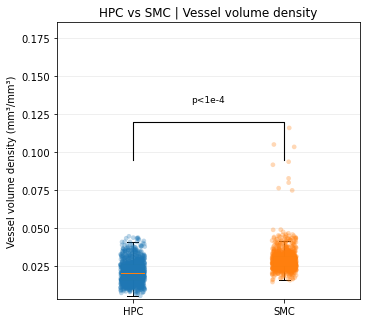

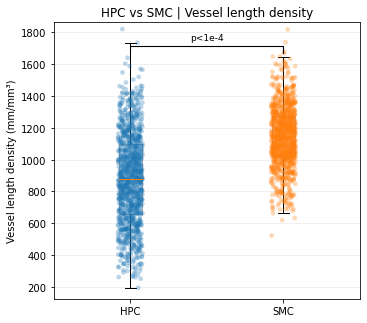

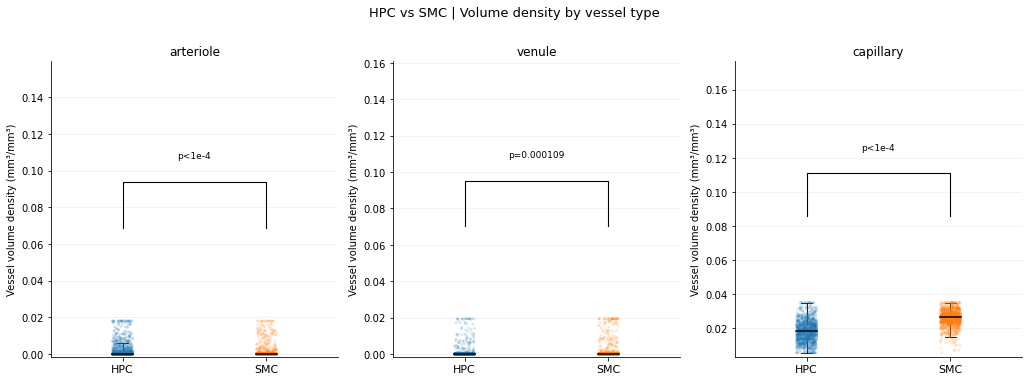

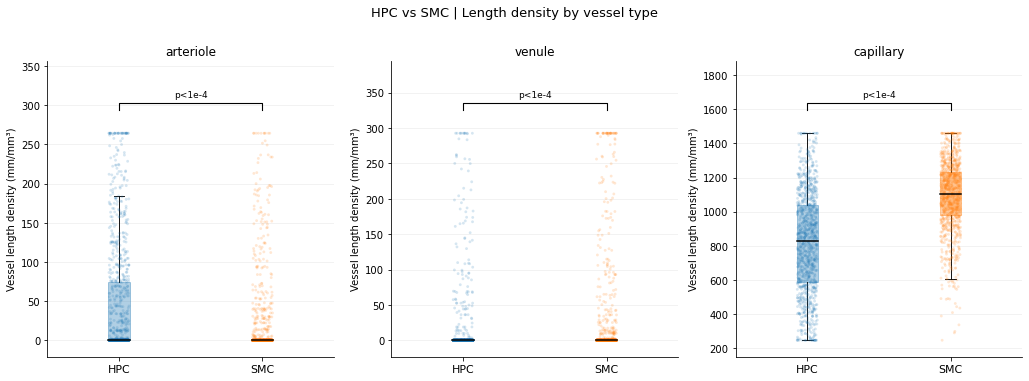

In [8]:
all_stats = []  # collector for all stat rows

if not density_all.empty:
    # total density
    df_total = density_all[density_all["type"] == "total"]

    st_vvd = plot_region_metric_boxplot(
        df_total, "vessel_volume_density", "Vessel volume density (mm³/mm³)",
        "HPC vs SMC | Vessel volume density",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_vessel_volume_density.png"))

    st_vld = plot_region_metric_boxplot(
        df_total, "vessel_length_density", "Vessel length density (mm/mm³)",
        "HPC vs SMC | Vessel length density",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_vessel_length_density.png"))

    # density by vessel type
    st_vvd_type = plot_region_by_type_boxplots(
        density_all, "vessel_volume_density", "Vessel volume density (mm³/mm³)",
        "HPC vs SMC | Volume density by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_volume_density_by_type.png"))

    st_vld_type = plot_region_by_type_boxplots(
        density_all, "vessel_length_density", "Vessel length density (mm/mm³)",
        "HPC vs SMC | Length density by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_length_density_by_type.png"))

    for st in [st_vvd, st_vld, st_vvd_type, st_vld_type]:
        if not st.empty: all_stats.append(st)

---
## 4. Diameter & length by vessel type

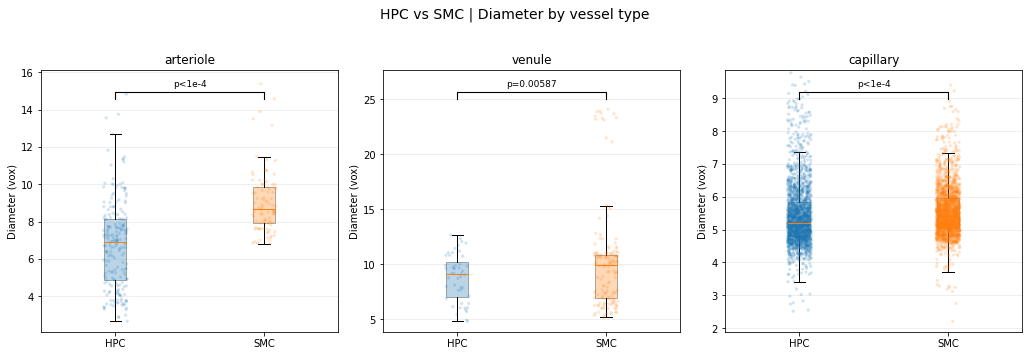

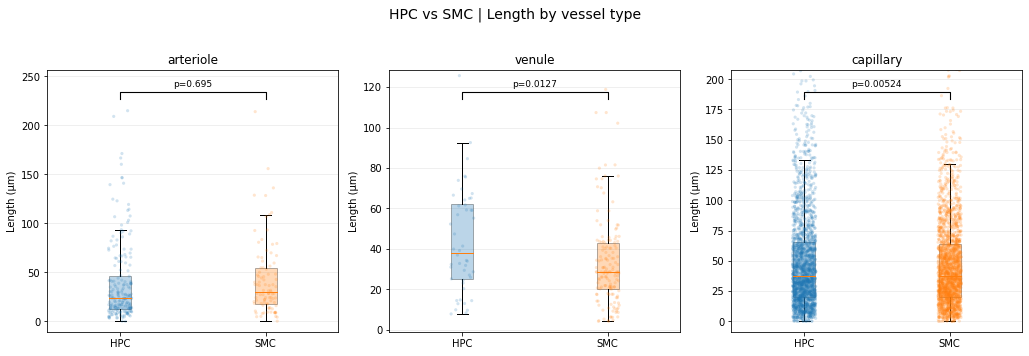

In [5]:
if not dl_all.empty:
    dl_all = _normalize_types(dl_all, col="type")

    st_diam = plot_region_by_type_boxplots(
        dl_all, "diameter_vox", "Diameter (vox)",
        "HPC vs SMC | Diameter by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_diameter_by_type.png"))

    st_len = plot_region_by_type_boxplots(
        dl_all, "length_um", "Length (µm)",
        "HPC vs SMC | Length by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_length_by_type.png"))

    for st in [st_diam, st_len]:
        if not st.empty: all_stats.append(st)

---
## 5. Boundary conditions

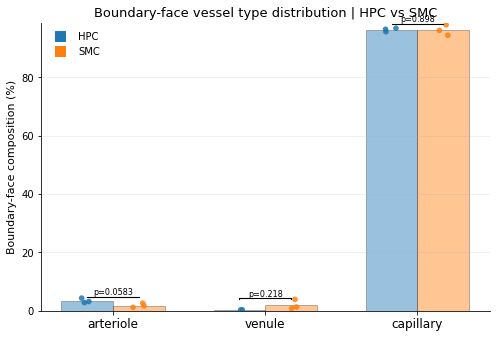

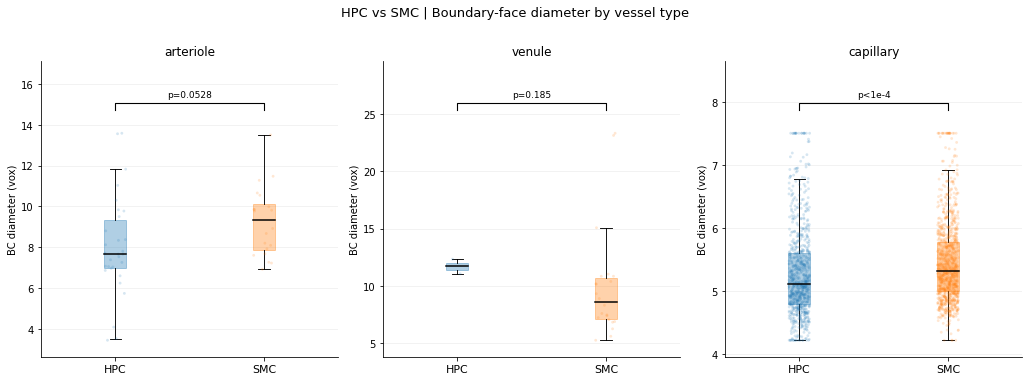

In [12]:
if not bc_pooled.empty:
    st_bc_kind = plot_bc_kind_distribution(
        bc_pooled,
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_BC_kind_distribution.png"))
    if not st_bc_kind.empty: all_stats.append(st_bc_kind)

if not bc_long.empty:
    bc_long_norm = _normalize_types(bc_long.copy(), col="type") \
        if "type" in bc_long.columns \
        else _normalize_types(bc_long.rename(columns={"vessel_type": "type"}), col="type")

    st_bc_diam = plot_region_by_type_boxplots(
        bc_long_norm, "diameter", "BC diameter (vox)",
        "HPC vs SMC | Boundary-face diameter by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_BC_diameter_by_type.png"))
    if not st_bc_diam.empty: all_stats.append(st_bc_diam)
else:
    print("[skip] BC long diameter — files not found.")

---
## 6. Connectivity — min-cut & redundancy

In [ ]:
if not mincut.empty:
    st_mc = plot_region_metric_boxplot(
        mincut, "min_cut_value", "Min-cut value",
        "HPC vs SMC | A→V min-cut (connectivity)",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_mincut.png"))
    if not st_mc.empty: all_stats.append(st_mc)

    st_cut_e = plot_region_metric_boxplot(
        mincut, "n_cut_edges", "# cut edges",
        "HPC vs SMC | Number of cut edges",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_n_cut_edges.png"))
    if not st_cut_e.empty: all_stats.append(st_cut_e)

if not redundancy.empty:
    st_red = plot_region_metric_boxplot(
        redundancy, "edge_disjoint_AV", "Edge-disjoint A→V paths",
        "HPC vs SMC | Network redundancy (edge-disjoint paths)",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_edge_disjoint.png"))
    if not st_red.empty: all_stats.append(st_red)

    if "shortest_path_len_median_um" in redundancy.columns:
        st_sp = plot_region_metric_boxplot(
            redundancy, "shortest_path_len_median_um", "Median shortest path (µm)",
            "HPC vs SMC | Median A→V shortest path length",
            out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_shortest_path_median.png"))
        if not st_sp.empty: all_stats.append(st_sp)

---
## 7. Saturation

In [ ]:
if not saturation.empty:
    for col, label in [
        ("saturation_ac_edges",    "Saturation A-side (fraction)"),
        ("saturation_vc_edges",    "Saturation V-side (fraction)"),
        ("n_ac_cap_edges_total",   "A-C capillary edges total"),
        ("n_vc_cap_edges_total",   "V-C capillary edges total"),
        ("ac_frontier_nodes_total","A-C frontier nodes total"),
        ("vc_nodes_reached",       "Venous nodes reached"),
    ]:
        if col not in saturation.columns:
            print(f"[skip] {col} not in saturation df")
            continue
        st = plot_region_metric_boxplot(
            saturation, col, label,
            f"HPC vs SMC | {label}",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
        if not st.empty: all_stats.append(st)

---
## 8. Major tree coverage

In [ ]:
if not summary.empty:
    for col, label in [
        ("art_major1_pct_edges", "Arteriole major tree coverage (% edges)"),
        ("art_major1_pct_nodes", "Arteriole major tree coverage (% nodes)"),
        ("ven_major1_pct_edges", "Venule major tree coverage (% edges)"),
        ("ven_major1_pct_nodes", "Venule major tree coverage (% nodes)"),
        ("n_major_arteriole_trees", "# major arteriole trees"),
        ("n_major_venule_trees",    "# major venule trees"),
        ("n_arteriole_components",  "# arteriole components"),
        ("n_venule_components",     "# venule components"),
    ]:
        if col not in summary.columns:
            print(f"[skip] {col} not in summary df")
            continue
        st = plot_region_metric_boxplot(
            summary, col, label,
            f"HPC vs SMC | {label}",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
        if not st.empty: all_stats.append(st)

    # HDN
    for col, label in [
        ("HDN_frac", "High-degree node fraction"),
        ("HDN_n",    "# high-degree nodes"),
    ]:
        if col in summary.columns:
            st = plot_region_metric_boxplot(
                summary, col, label,
                f"HPC vs SMC | {label}",
                out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
            if not st.empty: all_stats.append(st)

---
## 9. Save all stats

In [ ]:
if all_stats:
    df_stats = pd.concat(all_stats, ignore_index=True)
    stats_path = os.path.join(OUT_DIR, "HPC_vs_SMC_all_stats.csv")
    df_stats.to_csv(stats_path, index=False)
    print(f"Saved {len(df_stats)} stat rows to: {stats_path}")
    print(df_stats[["metric", "HPC_n", "SMC_n", "HPC_median", "SMC_median", "p_value"]].to_string(index=False))
else:
    print("No stats to save.")

print(f"\nAll plots saved in: {OUT_DIR}")